# Three-layer recovery timecourse plots

Scratch notebook for tuning the example-recovery figure style before exporting PDFs
for the paper. Loads `final_three_layer_msma_fixed` and evaluates on:

- its own held-out test split (`multi_source_multi_active`, in-distribution)
- the `single_source_shared_position` scenario (zero-shot transfer)

matching the two rows in `tab:results`. Tinker with `STYLE` and `plot_recovery` below;
nothing here writes into the paper repo until the export cell at the bottom is run
deliberately.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "scripts"))
import eval_mich  # noqa: E402

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
run_dir, ckpt_path, full_cfg = eval_mich.resolve_run(
    checkpoint=None,
    project="mich-bold-inversion",
    network="final_three_layer_msma_fixed",
    ckpt_tag="best",
)
model, model_kind, ckpt = eval_mich.load_model(full_cfg, ckpt_path, device)
print(model_kind, ckpt_path)

pinn /media/RCPNAS/Data2/sengupta/inversion/results/mich-bold-inversion/final_three_layer_msma_fixed/checkpoints/best.ckpt


In [3]:
N_SAMPLES = 64

h5_cache_cfg = full_cfg.datamodule.h5_cache

batches = {
    "in_distribution": eval_mich.load_test_split_batch(full_cfg, N_SAMPLES, device)[0],
    "shared_position": eval_mich.load_file_batch(
        REPO_ROOT / "data" / "simulations-three_layer_single_source_shared_position.h5",
        N_SAMPLES,
        h5_cache_cfg,
        device,
    ),
}
{k: v["bold"].shape for k, v in batches.items()}

{'in_distribution': torch.Size([64, 3, 100, 10, 10]),
 'shared_position': torch.Size([64, 3, 100, 10, 10])}

In [4]:
preds = {}
for name, batch in batches.items():
    z_hat, pred_neural, pred_bold = eval_mich.infer_pinn(model, batch)
    preds[name] = {"z_hat": z_hat, "pred_neural": pred_neural, "pred_bold": pred_bold}
list(preds)

['in_distribution', 'shared_position']

## Enumerate real sources + off-source voxels

Every sample can have more than one real source (across layers); this flattens each
dataset into a list of `(sample_idx, layer, h, w)` source records, plus one deliberately
off-source voxel per sample per layer, so a specific example is addressable by index
when picking which ones to export later.

In [5]:
def enumerate_sources(batch):
    """[(sample_idx, layer, h, w), ...] for every real source in the batch."""
    source_position = batch["source_position"].cpu()
    source_layer = batch["source_layer"].cpu()
    num_sources = batch["num_sources"].cpu()
    records = []
    for b in range(source_position.shape[0]):
        for s in range(int(num_sources[b])):
            l = int(source_layer[b, s])
            h, w = int(source_position[b, s, 0]), int(source_position[b, s, 1])
            records.append((b, l, h, w))
    return records


def off_source_voxel(batch, sample_idx, layer, H=10, W=10):
    source_position = batch["source_position"][sample_idx].cpu()
    num_sources = int(batch["num_sources"][sample_idx])
    source_layer = batch["source_layer"][sample_idx].cpu()
    occupied = {
        (int(source_position[s, 0]), int(source_position[s, 1]))
        for s in range(num_sources)
        if int(source_layer[s]) == layer
    }
    return model._pick_off_source_voxel(
        torch.tensor([h for h, w in occupied]) if occupied else torch.tensor([]),
        torch.tensor([w for h, w in occupied]) if occupied else torch.tensor([]),
        H,
        W,
    )


sources = {name: enumerate_sources(batch) for name, batch in batches.items()}
{name: len(recs) for name, recs in sources.items()}

{'in_distribution': 490, 'shared_position': 165}

## Per-source Pearson, to pick representative examples

Ranks every source record by its own Pearson r against the paper's headline numbers
(`0.649` in-distribution, `0.772` shared-position) so you can grab a "typical" example
rather than eyeballing randomly.

In [6]:
def pearson(a, b):
    a = a - a.mean()
    b = b - b.mean()
    denom = (a.norm() * b.norm()).clamp(min=1e-8)
    return float((a * b).sum() / denom)


def rank_sources(name):
    batch = batches[name]
    pred_neural = preds[name]["pred_neural"]
    rows = []
    for b, l, h, w in sources[name]:
        true_trace = batch["neural"][b, l, :, h, w].cpu()
        pred_trace = pred_neural[b, l, :, h, w].detach().cpu()
        rows.append((b, l, h, w, pearson(pred_trace, true_trace)))
    return sorted(rows, key=lambda r: r[-1])


ranked = {name: rank_sources(name) for name in batches}
for name, rows in ranked.items():
    rs = np.array([r[-1] for r in rows])
    print(f"{name}: median r={np.median(rs):.3f}  (target {'-'})  n={len(rows)}")

in_distribution: median r=0.954  (target -)  n=490
shared_position: median r=0.923  (target -)  n=165


In [7]:
def closest_to(rows, target_r):
    return min(rows, key=lambda r: abs(r[-1] - target_r))


example_picks = {
    "in_distribution": closest_to(ranked["in_distribution"], 0.9),
    "shared_position": closest_to(ranked["shared_position"], 0.91),
}
example_picks

{'in_distribution': (54, 2, 4, 8, 0.900303840637207),
 'shared_position': (47, 2, 7, 1, 0.9111930131912231)}

## The plot to tinker with

Edit `STYLE` and re-run `plot_recovery` below -- this is the one to iterate on. Nothing
saves to disk until the export cell at the end.

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.


findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


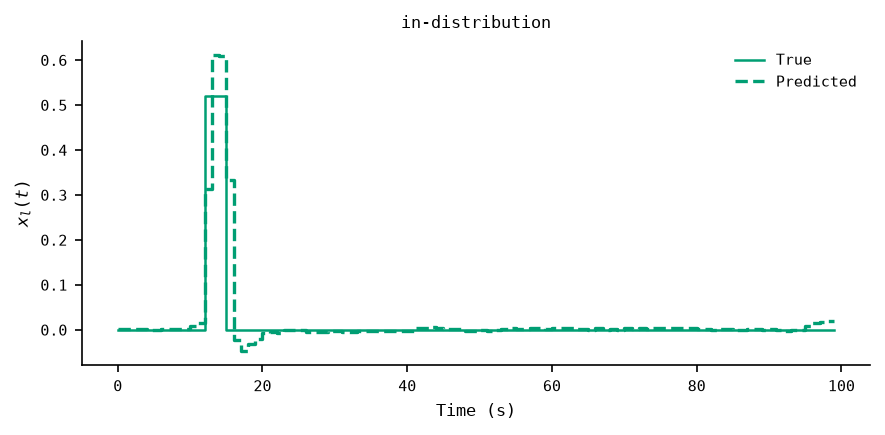

In [8]:
STYLE = dict(
    figsize=(6, 3),      # single-column width in inches, tweak freely
    true_lw=1.2,
    pred_lw=1.6,
    true_ls="-",
    pred_ls="--",
    fontsize=8,
    tr=1.0,                   # seconds/sample, for the x-axis
    dpi=150,
    font="monospace",
)
plt.rcParams["font.family"] = STYLE["font"]
# mathtext (the "$...$" parts, e.g. the y-label) ignores font.family, so set it separately
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = STYLE["font"]
plt.rcParams["mathtext.it"] = f"{STYLE['font']}:italic"
plt.rcParams["mathtext.bf"] = f"{STYLE['font']}:bold"

# Colour now encodes SIGNAL identity (BOLD vs. neural), not true/predicted -- both lines
# in a signal's row share one colour. True/predicted is instead encoded by linestyle only
# (solid vs. dashed), so the two-column legend below reads as one column of colours
# ("BOLD"/"Neural") and one column of linestyles ("True"/"Predicted"), independent of
# each other. Colours are the Okabe-Ito colourblind-safe pair (vermillion / bluish-green)
# rather than pure #ff0000/#00ff00 -- these still read as "red" and "green" to typical
# vision but stay distinguishable under protanopia/deuteranopia. Draw style (BOLD is
# continuous -> plot; neural is piecewise-constant rectangular pulses -> step) stays
# per-signal too.
SIGNAL_INFO = {
    "x": {
        "batch_key": "neural", "pred_key": "pred_neural", "ylabel": r"$x_l(t)$",
        "draw": "step", "color": "#009E73", "legend_label": "Neural",  # Okabe-Ito bluish green
    },
    "bold": {
        "batch_key": "bold", "pred_key": "pred_bold", "ylabel": r"$y_l(t)$",
        "draw": "plot", "color": "#D55E00", "legend_label": "BOLD",  # Okabe-Ito vermillion
    },
}


def plot_recovery(name, sample_idx, layer, h, w, signal="x", ax=None, title=None):
    batch = batches[name]
    info = SIGNAL_INFO[signal]
    pred_full = preds[name][info["pred_key"]]
    true_trace = batch[info["batch_key"]][sample_idx, layer, :, h, w].cpu().numpy()
    pred_trace = pred_full[sample_idx, layer, :, h, w].detach().cpu().numpy()
    t = np.arange(len(true_trace)) * STYLE["tr"]
    draw = getattr(plt.Axes, info["draw"])  # "plot" or "step", per signal

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=STYLE["figsize"], dpi=STYLE["dpi"])
    # True (solid) drawn first, Predicted (dashed) drawn on top: same colour per signal
    # now, so draw order only matters for which linestyle reads clearly where the two
    # coincide -- a dashed line breaking up a solid one underneath is the legible order.
    draw(ax, t, true_trace, color=info["color"], lw=STYLE["true_lw"],
         ls=STYLE["true_ls"], label="True", zorder=2)
    draw(ax, t, pred_trace, color=info["color"], lw=STYLE["pred_lw"],
         ls=STYLE["pred_ls"], label="Predicted", zorder=3)
    ax.set_xlabel("Time (s)", fontsize=STYLE["fontsize"])
    ax.set_ylabel(info["ylabel"], fontsize=STYLE["fontsize"])
    ax.tick_params(labelsize=STYLE["fontsize"] - 1)
    ax.spines[["top", "right"]].set_visible(False)
    if title:
        ax.set_title(title, fontsize=STYLE["fontsize"])
    if own_fig:
        ax.legend(fontsize=STYLE["fontsize"] - 1, frameon=False)
        fig.tight_layout()
        return fig
    return ax


b, l, h, w, r = example_picks["in_distribution"]
fig = plot_recovery("in_distribution", b, l, h, w,
                     title=f"in-distribution")
plt.show()

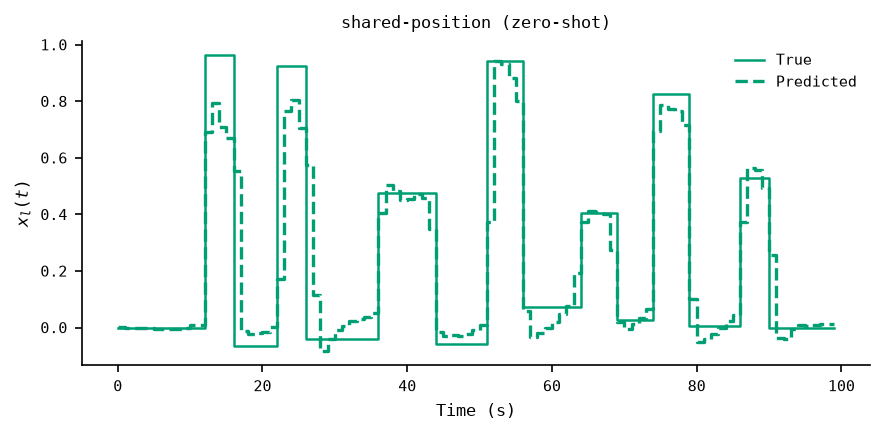

In [9]:
b, l, h, w, r = example_picks["shared_position"]
fig = plot_recovery("shared_position", b, l, h, w,
                     title=f"shared-position (zero-shot)")
plt.show()

### Source vs. off-source, side by side

Same style, paired panels -- useful for the off-source-gap point in the text.

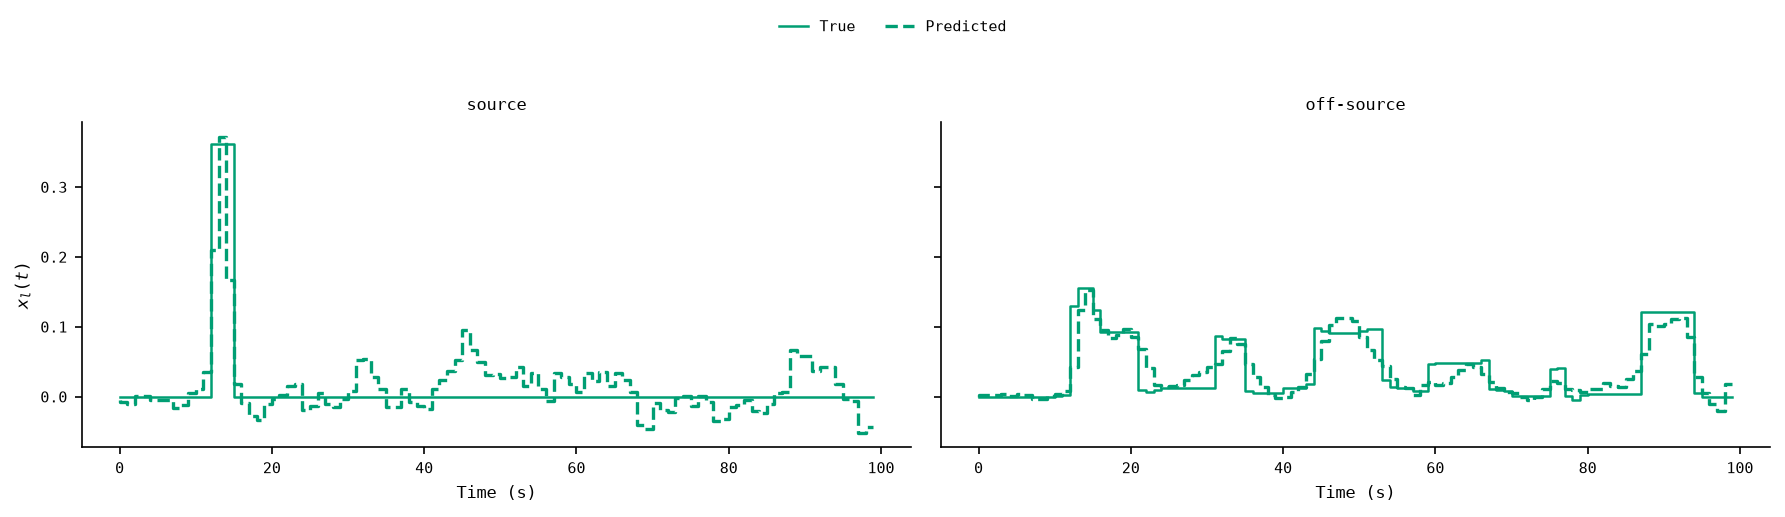

In [10]:
def plot_source_vs_off_source(name, sample_idx, layer):
    batch = batches[name]
    src_pos = batch["source_position"][sample_idx].cpu()
    num_src = int(batch["num_sources"][sample_idx])
    src_layer = batch["source_layer"][sample_idx].cpu()
    h_src = w_src = None
    for s in range(num_src):
        if int(src_layer[s]) == layer:
            h_src, w_src = int(src_pos[s, 0]), int(src_pos[s, 1])
            break
    if h_src is None:
        raise ValueError(f"sample {sample_idx} has no source in layer {layer}")
    h_off, w_off = off_source_voxel(batch, sample_idx, layer)

    fig, axes = plt.subplots(1, 2, figsize=(STYLE["figsize"][0] * 2, STYLE["figsize"][1]),
                              dpi=STYLE["dpi"], sharey=True)
    plot_recovery(name, sample_idx, layer, h_src, w_src, ax=axes[0], title="source")
    plot_recovery(name, sample_idx, layer, h_off, w_off, ax=axes[1], title="off-source")
    axes[1].set_ylabel("")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=STYLE["fontsize"] - 1, frameon=False,
               loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.15))
    fig.tight_layout()
    return fig


b, l, *_ = example_picks["in_distribution"]
_ = plot_source_vs_off_source("in_distribution", b, l)
plt.show()

## Two paper figures

Each figure now shows the full picture per layer: BOLD (the model's input) on top,
neural drive (what it infers) below -- two rows per layer, six rows total for L=3.
Kept as two separate rows rather than a twin-axis overlay on purpose: only ever two
colours anywhere (true vs. predicted), never one per signal, so it stays
colourblind-safe and doesn't get visually busy. Toggle with `include_bold=False` in
`plot_recovery_stacked` to go back to neural-only.

**Figure 1 -- three-layer, multi-source (in-distribution).** `multi_source_multi_active`
places sources independently per layer, so a meaningful "all three layers" figure has to
show each layer's *own* real source location, not one shared `(h, w)` column (a shared
column mostly shows two flat, inactive rows -- checked, not informative). `positions` below
is `{layer: (h, w)}`, one real source per layer, from a sample where all three layers are
simultaneously active.

**Figure 2 -- zero-shot transfer (shared-position).** Same function, but here `single_source_shared_position`
genuinely does share one `(h, w)` column across every active layer by construction, so a
single shared position is the correct (not simplified) way to plot it -- this is the
"zero-shot" condition: MICH trained only on `multi_source_multi_active` and never saw this
scenario's structure during training.

In [11]:
from matplotlib.lines import Line2D
from mich.utils.plotting import LAYER_NAMES

figsize = (3.6, 4.0)  # 6 rows (BOLD+neural x 3 layers), still sized for ~0.49*textwidth


def plot_recovery_stacked(name, sample_idx, positions, suptitle=None, include_bold=True):
    """positions: a single (h, w) shared across every layer, or a
    {layer_idx: (h, w)} dict giving each layer its own position.

    include_bold: two rows per layer (BOLD, then neural) instead of one --
    BOLD is the model's input, neural drive is what it infers, so
    top-to-bottom within a layer reads as the causal story. Title only on
    the BOLD row (layer name); the neural row's own y-label already says
    what it is, so it doesn't need a repeated title.
    """
    pred_neural = preds[name]["pred_neural"]
    n_layers = pred_neural.shape[1]
    if isinstance(positions, tuple):
        positions = {layer: positions for layer in range(n_layers)}
    signals = ["bold", "x"] if include_bold else ["x"]
    n_rows = n_layers * len(signals)
    fig, axes = plt.subplots(
        n_rows, 1, figsize=figsize,
        dpi=STYLE["dpi"], sharex=True, constrained_layout=True,
    )
    row = 0
    for layer_row in range(n_layers):
        channel_idx = n_layers - 1 - layer_row  # top-to-bottom = superficial-to-deep
        h, w = positions[channel_idx]
        for sig_idx, signal in enumerate(signals):
            title = LAYER_NAMES[layer_row] if sig_idx == 0 else None
            plot_recovery(name, sample_idx, channel_idx, h, w, signal=signal, ax=axes[row], title=title)
            row += 1
    for ax in axes[:-1]:
        ax.set_xlabel("")
    # Legend at the bottom, not the top: a top legend collides with the first
    # row's own title ("Superficial") -- moving it below the last row avoids that
    # entirely rather than fiddling with anchor offsets to dodge it.
    #
    # Two-column compound legend, built from proxy handles rather than
    # axes[0].get_legend_handles_labels(): axes[0] only has one signal's two
    # lines, but the colour column needs both signals' colours regardless of
    # which row happens to be first. ncol=2 with this handle order fills
    # column-major (verified), giving colour (BOLD/Neural) in column 1 and
    # linestyle (True/Predicted) in column 2, independent of each other.
    legend_handles = [
        Line2D([], [], color=SIGNAL_INFO["bold"]["color"], lw=STYLE["pred_lw"],
               label=SIGNAL_INFO["bold"]["legend_label"]),
        Line2D([], [], color=SIGNAL_INFO["x"]["color"], lw=STYLE["pred_lw"],
               label=SIGNAL_INFO["x"]["legend_label"]),
        Line2D([], [], color="black", lw=STYLE["true_lw"], ls=STYLE["true_ls"], label="True"),
        Line2D([], [], color="black", lw=STYLE["pred_lw"], ls=STYLE["pred_ls"], label="Predicted"),
    ]
    fig.legend(handles=legend_handles, fontsize=STYLE["fontsize"] - 1, frameon=False,
               loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.06))
    if suptitle:
        fig.suptitle(suptitle, fontsize=STYLE["fontsize"] + 1, y=1.02)
    return fig


def find_all_layers_active_samples(name):
    """sample_idx -> {layer: (h, w, r)} for every sample where all n_layers
    layers have a real source (needed for a genuine per-layer-source figure)."""
    n_layers = preds[name]["pred_neural"].shape[1]
    by_sample = {}
    for b, l, h, w, r in ranked[name]:
        by_sample.setdefault(b, {})[l] = (h, w, r)
    return {b: d for b, d in by_sample.items() if len(d) == n_layers}


def closest_mean_r(candidates, target_r):
    def mean_r(d):
        return sum(v[2] for v in d.values()) / len(d)
    best_b = min(candidates, key=lambda b: abs(mean_r(candidates[b]) - target_r))
    return best_b, candidates[best_b]


in_dist_median_r = float(np.median([r for *_, r in ranked["in_distribution"]]))
all_active = find_all_layers_active_samples("in_distribution")
fig1_sample, fig1_layers = closest_mean_r(all_active, in_dist_median_r)
fig1_positions = {l: (h, w) for l, (h, w, r) in fig1_layers.items()}
fig1_mean_r = sum(r for *_, r in fig1_layers.values()) / len(fig1_layers)
print(f"fig1: sample={fig1_sample}  per-layer r={ {l: round(r,3) for l,(_,_,r) in fig1_layers.items()} }  mean r={fig1_mean_r:.3f}")

fig1: sample=62  per-layer r={2: 0.956, 1: 0.945, 0: 0.962}  mean r=0.955


## Merged figure (both conditions side by side)

Trying whether combining Figures 2+3 into one 6-row x 2-column figure (columns =
in-distribution / zero-shot) saves vertical space vs. two separate stacked
figures -- one shared legend and one shared row of BOLD/neural labels instead
of two full copies. Render and check it looks OK before wiring it into the
paper; if it doesn't save enough (or reads worse), revert to the two-figure
version above.

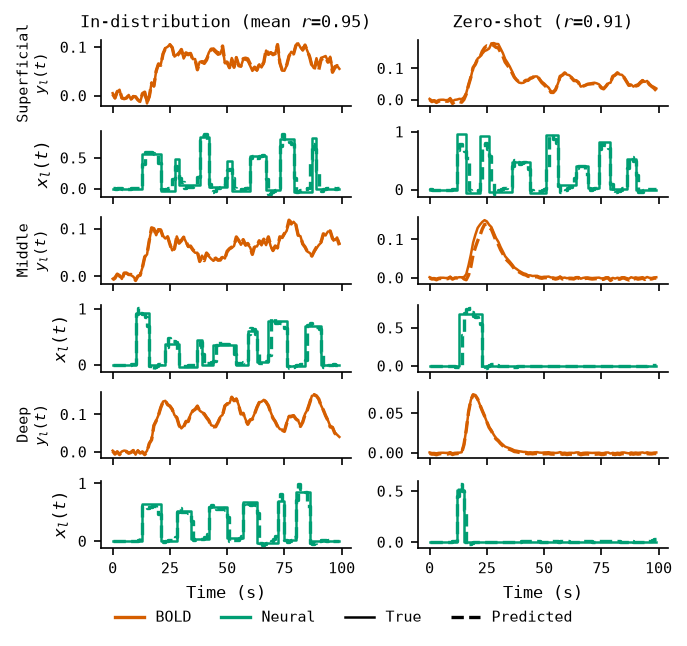

In [12]:
def plot_recovery_combined(conditions, suptitle=None, include_bold=True):
    """conditions: [(name, sample_idx, positions, col_title), ...], one per column."""
    n_layers = preds[conditions[0][0]]["pred_neural"].shape[1]
    signals = ["bold", "x"] if include_bold else ["x"]
    n_rows = n_layers * len(signals)
    n_cols = len(conditions)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(figsize[0] * n_cols * 0.62, figsize[1]),
        dpi=STYLE["dpi"], sharex=True, constrained_layout=True,
    )
    if n_cols == 1:
        axes = axes[:, None]

    for col, (name, sample_idx, positions, col_title) in enumerate(conditions):
        if isinstance(positions, tuple):
            positions = {layer: positions for layer in range(n_layers)}
        row = 0
        for layer_row in range(n_layers):
            channel_idx = n_layers - 1 - layer_row  # top-to-bottom = superficial-to-deep
            h, w = positions[channel_idx]
            for sig_idx, signal in enumerate(signals):
                ax = axes[row, col]
                plot_recovery(name, sample_idx, channel_idx, h, w, signal=signal, ax=ax)
                if col == 0 and sig_idx == 0:
                    ax.set_ylabel(f"{LAYER_NAMES[layer_row]}\n" + ax.get_ylabel(), fontsize=STYLE["fontsize"] - 1)
                elif col > 0:
                    ax.set_ylabel("")
                if row < n_rows - 1:
                    ax.set_xlabel("")
                row += 1
        axes[0, col].set_title(col_title, fontsize=STYLE["fontsize"])

    legend_handles = [
        Line2D([], [], color=SIGNAL_INFO["bold"]["color"], lw=STYLE["pred_lw"],
               label=SIGNAL_INFO["bold"]["legend_label"]),
        Line2D([], [], color=SIGNAL_INFO["x"]["color"], lw=STYLE["pred_lw"],
               label=SIGNAL_INFO["x"]["legend_label"]),
        Line2D([], [], color="black", lw=STYLE["true_lw"], ls=STYLE["true_ls"], label="True"),
        Line2D([], [], color="black", lw=STYLE["pred_lw"], ls=STYLE["pred_ls"], label="Predicted"),
    ]
    fig.legend(handles=legend_handles, fontsize=STYLE["fontsize"] - 1, frameon=False,
               loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05))
    if suptitle:
        fig.suptitle(suptitle, fontsize=STYLE["fontsize"] + 1, y=1.04)
    return fig


b2, l2, h2, w2, r2 = example_picks["shared_position"]
fig_combined = plot_recovery_combined([
    ("in_distribution", fig1_sample, fig1_positions, f"In-distribution (mean $r$={fig1_mean_r:.2f})"),
    ("shared_position", b2, (h2, w2), f"Zero-shot ($r$={r2:.2f})"),
])
plt.show()

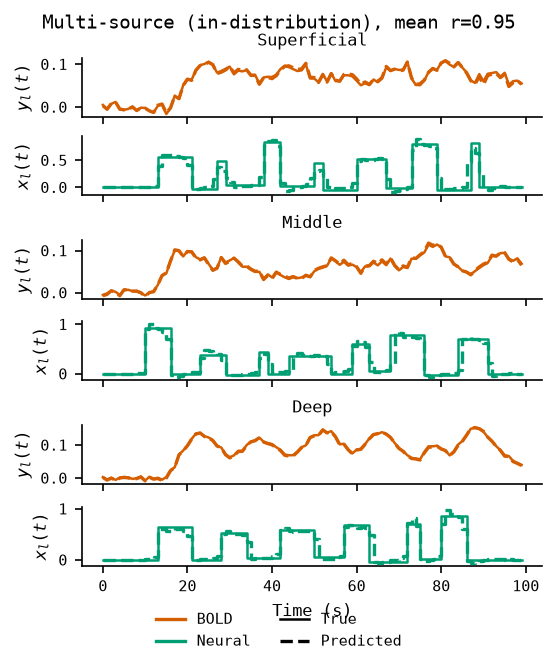

In [13]:
fig = plot_recovery_stacked(
    "in_distribution", fig1_sample, fig1_positions,
    suptitle=f"Multi-source (in-distribution), mean r={fig1_mean_r:.2f}",
)
plt.show()

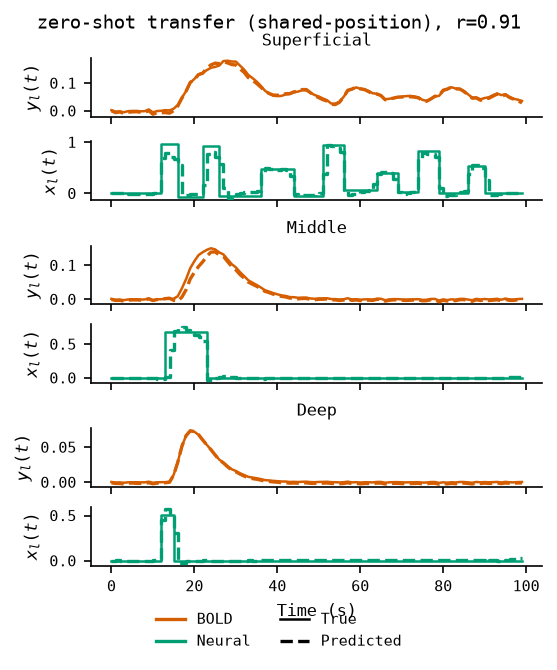

In [14]:
b, l, h, w, r = example_picks["shared_position"]
fig = plot_recovery_stacked(
    "shared_position", b, (h, w),
    suptitle=f"zero-shot transfer (shared-position), r={r:.2f}",
)
plt.show()

## Export

Saves the two figures above (Figure 1: three-layer multi-source, Figure 2: zero-shot
transfer) as PDFs into `../../paper/mich/figures/recovery_examples/`. Re-run the two
demo cells above first if you have changed `STYLE` or picked different examples --
this cell re-plots from current state, it does not reuse old figure objects.

In [15]:
out_dir = REPO_ROOT.parent / "paper" / "mich" / "figures" / "recovery_examples"
out_dir.mkdir(parents=True, exist_ok=True)

fig1 = plot_recovery_stacked(
    "in_distribution", fig1_sample, fig1_positions,
    suptitle=f"Multi-source (in-distribution), mean r={fig1_mean_r:.2f}",
)
fig1.savefig(out_dir / "recovery_multi_source.pdf", bbox_inches="tight")

b, l, h, w, r = example_picks["shared_position"]
fig2 = plot_recovery_stacked(
    "shared_position", b, (h, w),
    suptitle=f"zero-shot transfer (shared-position), r={r:.2f}",
)
fig2.savefig(out_dir / "recovery_zero_shot.pdf", bbox_inches="tight")

plt.close(fig1)
plt.close(fig2)
list(out_dir.glob("*.pdf"))

fig_combined_export = plot_recovery_combined([
    ("in_distribution", fig1_sample, fig1_positions, f"In-distribution (mean $r$={fig1_mean_r:.2f})"),
    ("shared_position", b, (h, w), f"Zero-shot ($r$={r:.2f})"),
])
fig_combined_export.savefig(out_dir / "recovery_combined.pdf", bbox_inches="tight")
plt.close(fig_combined_export)
list(out_dir.glob("*.pdf"))

[PosixPath('/media/RCPNAS/Data2/sengupta/inversion/paper/mich/figures/recovery_examples/recovery_multi_source.pdf'),
 PosixPath('/media/RCPNAS/Data2/sengupta/inversion/paper/mich/figures/recovery_examples/recovery_combined.pdf'),
 PosixPath('/media/RCPNAS/Data2/sengupta/inversion/paper/mich/figures/recovery_examples/recovery_zero_shot.pdf')]